In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
words = open('data/names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [3]:
# shuffle up the words
import random
random.seed(42)
random.shuffle(words)

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# build the dataset
block_size = 8 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class WaveNet(nn.Module):
    def __init__(self, vocab_size, n_embd=10, n_hidden=68):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, n_embd)
        
        self.conv1 = nn.Conv1d(n_embd,   n_hidden, kernel_size=2, dilation=1)
        self.bn1   = nn.BatchNorm1d(n_hidden)
        
        self.conv2 = nn.Conv1d(n_hidden, n_hidden, kernel_size=2, dilation=2)
        self.bn2   = nn.BatchNorm1d(n_hidden)
        
        self.conv3 = nn.Conv1d(n_hidden, n_hidden, kernel_size=2, dilation=4)
        self.bn3   = nn.BatchNorm1d(n_hidden)
        
        self.fc = nn.Linear(n_hidden, vocab_size)
        
        with torch.no_grad():
            self.fc.weight *= 0.1

    def forward(self, x):
        # x entering forward:         (B, L)               e.g. (32, 8) — batch of token indices
        
        x = self.embedding(x)        # (B, L, n_embd)      e.g. (32, 8, 10)  — each token becomes a vector
        x = x.transpose(1, 2)        # (B, n_embd, L)      e.g. (32, 10, 8)  — Conv1d wants channels second
        
        x = F.pad(x, (1, 0))         # (B, n_embd, L+1)    e.g. (32, 10, 9)  — pad left by dilation=1 to preserve length
        x = self.conv1(x)            # (B, n_hidden, L)     e.g. (32, 68, 8)  — kernel=2,dilation=1 eats the 1 pad, channels n_embd→n_hidden
        x = self.bn1(x)              # (B, n_hidden, L)     e.g. (32, 68, 8)  — normalise across batch, shape unchanged
        x = torch.tanh(x)            # (B, n_hidden, L)     e.g. (32, 68, 8)  — activation, shape unchanged
        
        x = F.pad(x, (2, 0))         # (B, n_hidden, L+2)  e.g. (32, 68, 10) — pad left by dilation=2 to preserve length
        x = self.conv2(x)            # (B, n_hidden, L)     e.g. (32, 68, 8)  — kernel=2,dilation=2 eats the 2 pad, channels unchanged
        x = self.bn2(x)              # (B, n_hidden, L)     e.g. (32, 68, 8)  — normalise, shape unchanged
        x = torch.tanh(x)            # (B, n_hidden, L)     e.g. (32, 68, 8)  — activation, shape unchanged
        
        x = F.pad(x, (4, 0))         # (B, n_hidden, L+4)  e.g. (32, 68, 12) — pad left by dilation=4 to preserve length
        x = self.conv3(x)            # (B, n_hidden, L)     e.g. (32, 68, 8)  — kernel=2,dilation=4 eats the 4 pad, channels unchanged
        x = self.bn3(x)              # (B, n_hidden, L)     e.g. (32, 68, 8)  — normalise, shape unchanged
        x = torch.tanh(x)            # (B, n_hidden, L)     e.g. (32, 68, 8)  — activation, shape unchanged
        
        x = x[:, :, -1]              # (B, n_hidden)        e.g. (32, 68)     — take last timestep only, this has seen all L positions
        x = self.fc(x)               # (B, vocab_size)      e.g. (32, 27)     — project to logits over vocabulary
        return x


model = WaveNet(vocab_size)

parameters = list(model.parameters())
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

22601


In [12]:
max_steps = 100000
batch_size = 32
lossi = []

for i in range(max_steps):
    model.train()
    # mini-batch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    #update : simple SGD
    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    #track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps} {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/100000 3.3157
  10000/100000 2.0445
  20000/100000 2.1978
  30000/100000 2.1381
  40000/100000 1.7892
  50000/100000 2.3340
  60000/100000 2.1216
  70000/100000 2.1535
  80000/100000 3.0259
  90000/100000 2.0720


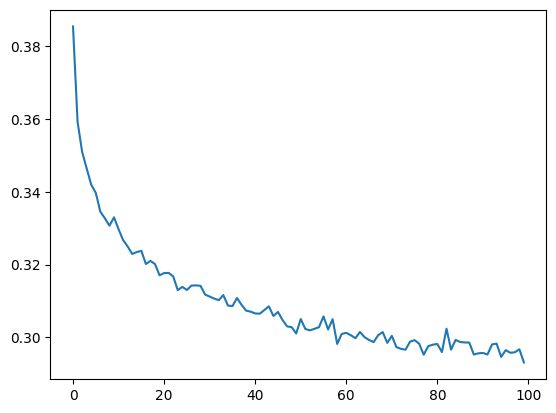

In [14]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [15]:
@torch.no_grad()
def split_loss(split):
    model.eval()
    X, Y = {'train': (Xtr, Ytr), 'dev': (Xdev, Ydev), 'test': (Xte, Yte)}[split]
    logits = model(X)
    loss = F.cross_entropy(logits, Y)
    print(f'{split} loss: {loss.item():.4f}')
    print(f"log loss - {split}: {loss.log10().item():.4f}")

split_loss('train')
split_loss('dev')

train loss: 1.9764
log loss - train: 0.2959
dev loss: 2.0702
log loss - dev: 0.3160


In [16]:
model.eval()
for _ in range(20) :
    out = []
    context = [0] * block_size
    while True:
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

erisetselynn.
hendelle.
juleiah.
shari.
kacenica.
hazin.
acson.
doselyn.
anisha.
esah.
brin.
zydan.
nizabelle.
zane.
marlett.
hailey.
brannet.
tydael.
efaja.
luviana.
